In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from go_ml.models.warmup_esm_finetune import ESMFinetune
from go_ml.data_utils import *
import pandas as pd
from tqdm import tqdm

checkpoint_path = "/home/andrew/GO_interp/checkpoints/esm_finetune_fin.ckpt"
model = ESMFinetune.load_from_checkpoint(checkpoint_path, strict=False)
print(f'Loaded model from {checkpoint_path}')

import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
go_term_map = {term: i for i, term in enumerate(go_terms)}
from collections import defaultdict
go_term_map = defaultdict(lambda: 0, go_term_map)

from torch.utils.data import DataLoader
from go_ml.data_utils import ProtFuncDataset, prot_func_collate
from go_ml.eval_utils import filter_annot_df
data_root = '/home/andrew/GO_interp/go_ml/gen_datasets/datasets'
dataset_labels = ['csa', 'llps', 'elms', 'biolip', 
                  'ip_repeat', 'ip_homologous_superfamily', 'ip_domain', 'ip_binding_site', 'ip_active_site']
dataset_dfs = [filter_annot_df(pd.read_csv(f'{data_root}/{label}_dataset.csv', sep='\t')) for label in dataset_labels]
dataset_ds = [ProtFuncDataset.from_annot_df(df, go_terms) for df in dataset_dfs]
dataset_dl = [DataLoader(ds, batch_size=1, collate_fn=prot_func_collate, shuffle=False) for ds in dataset_ds]
dl_dict = {label: dl for label, dl in zip(dataset_labels, dataset_dl)}


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/andrew/anaconda3/envs/goint/lib/python3.10/site-packages/pytorch_lightning/core/saving.py:191: Found keys that are in the model state dict but not in the checkpoint: ['model.embeddings.position_embeddings.weight']


Loaded model from /home/andrew/GO_interp/checkpoints/esm_finetune_fin.ckpt


In [3]:
import argparse
parser = argparse.ArgumentParser()
# parser.add_argument('--dataset', type=int, default=0, help='Index of dataset to use')
parser.add_argument('--gpu', type=int, default=0, help='GPU index to use')
parser.add_argument('--method', type=str, default='lig', help='Interpretability method to use')
parser.add_argument('--dataset', type=str, default='all', help='Dataset to use')
parser.add_argument('--overwrite', type=bool, default=False, help='Whether to overwrite existing attribution files')

args = parser.parse_args([])

if(args.dataset == 'all'):
    ds_labels = dataset_labels
else:
    ds_labels = [args.dataset]
print(f'Using datasets: {ds_labels}')

#get accessible devices
import torch
devices = [torch.device(f'cuda:{i}') for i in range(torch.cuda.device_count())]
device = devices[args.gpu]
model.to(device)
model.eval()
print('Loaded model to device', device)

Using datasets: ['csa', 'llps', 'elms', 'biolip', 'ip_repeat', 'ip_homologous_superfamily', 'ip_domain', 'ip_binding_site', 'ip_active_site']
Loaded model to device cuda:0


In [9]:
from go_ml.model_interp.ds_interp import *
args.method = 'lga'
print(f'Using interpretability method: {args.method}')
attrib_func = func_dict[args.method]

Using interpretability method: lga


In [ ]:

from go_ml.eval_utils import (gen_annot_mat, gen_seq_len_mask)
for ds_label in ds_labels:
    if(ds_label != 'llps'):
         continue
    print(f'Processing dataset {ds_label}')
    save_path = f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}/{args.method}_attr.pkl'
    if(os.path.exists(save_path) and not args.overwrite):
        print(f'Attribution file {save_path} already exists, skipping...')
        continue
    annot_df = dataset_dfs[dataset_labels.index(ds_label)]
    annot_dl = dl_dict[ds_label]
    attributions_l = attrib_func(model, annot_dl, device, go_term_map)
    if( len(attributions_l[0].shape) > 2):
        attr_dim = attributions_l[0].shape[-1]
    else:
        attr_dim = 1
    attributions = torch.zeros((len(annot_df), 850, attr_dim), dtype=torch.float32)
    # print('attributions shape', attributions.shape)
    cum_ind = 0
    for i, attributions_i in enumerate(attributions_l):
        cum_ind += attributions_i.shape[0]
        if(len(attributions_i.shape ) == 2):
            attributions_i = attributions_i.unsqueeze(-1)
        # print(attributions_i.shape, cum_ind)
        attributions[cum_ind - attributions_i.shape[0]:cum_ind, :attributions_i.shape[1], :] = attributions_i

    if(len(attributions.shape) > 2):
        attribution_scores = attributions.norm(dim=-1)
    else:
        attribution_scores = attributions
    attribution_scores = attribution_scores.detach().cpu().numpy()
    
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    with open(save_path, 'wb') as f:
            pickle.dump({'UniprotID': annot_df['UniprotID'], 'attribution_scores': attribution_scores, 
                        'seq_len_mask': seq_len_mask}, f)
            

Processing dataset llps


100%|██████████| 53/53 [00:06<00:00,  7.99it/s]


attributions shape torch.Size([53, 850, 1280])
torch.Size([1, 731, 1280]) 1
torch.Size([1, 710, 1280]) 2
torch.Size([1, 634, 1280]) 3
torch.Size([1, 594, 1280]) 4
torch.Size([1, 416, 1280]) 5
torch.Size([1, 658, 1280]) 6
torch.Size([1, 374, 1280]) 7
torch.Size([1, 507, 1280]) 8
torch.Size([1, 726, 1280]) 9
torch.Size([1, 664, 1280]) 10
torch.Size([1, 825, 1280]) 11
torch.Size([1, 695, 1280]) 12
torch.Size([1, 671, 1280]) 13
torch.Size([1, 626, 1280]) 14
torch.Size([1, 706, 1280]) 15
torch.Size([1, 184, 1280]) 16
torch.Size([1, 443, 1280]) 17
torch.Size([1, 252, 1280]) 18
torch.Size([1, 442, 1280]) 19
torch.Size([1, 473, 1280]) 20
torch.Size([1, 724, 1280]) 21
torch.Size([1, 743, 1280]) 22
torch.Size([1, 672, 1280]) 23
torch.Size([1, 558, 1280]) 24
torch.Size([1, 687, 1280]) 25
torch.Size([1, 707, 1280]) 26
torch.Size([1, 641, 1280]) 27
torch.Size([1, 299, 1280]) 28
torch.Size([1, 445, 1280]) 29
torch.Size([1, 742, 1280]) 30
torch.Size([1, 227, 1280]) 31
torch.Size([1, 728, 1280]) 32
to

In [ ]:
from go_ml.eval_utils import (gen_annot_mat, gen_seq_len_mask)
for ds_label in ds_labels:
    print(f'Processing dataset {ds_label}')
    save_path = f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}/{args.method}_attr.pkl'
    if(os.path.exists(save_path) and not args.overwrite):
        print(f'Attribution file {save_path} already exists, skipping...')
        continue
    annot_df = dataset_dfs[dataset_labels.index(ds_label)]
    annot_dl = dl_dict[ds_label]
    attributions_l, delta_l = attrib_func(model, annot_dl, device)
    attributions = torch.zeros((len(annot_df), 850, attributions_l[0].shape[-1]), dtype=torch.float32)
    cum_ind = 0
    for i, attributions_i in enumerate(attributions_l):
        cum_ind += attributions_i.shape[0]
        attributions[cum_ind - attributions_i.shape[0]:cum_ind, :attributions_i.shape[1], :] = attributions_i
    if(len(attribution_scores.shape) > 2):
        attribution_scores = torch.var(attributions, dim=-1)
    else:
        attribution_scores = attributions
    attribution_scores = attribution_scores.cpu().numpy()
    
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    with open(save_path, 'wb') as f:
            pickle.dump({'UniprotID': annot_df['UniprotID'], 'attribution_scores': attribution_scores, 
                        'seq_len_mask': seq_len_mask, 'attribution_mat': attributions}, f)

In [4]:
from go_ml.model_interp.ds_interp import *

In [ ]:
attrib_func = func_dict[args.method]
print(f'Using interpretability method: {args.method}')

from go_ml.eval_utils import (gen_annot_mat, gen_seq_len_mask)
for ds_label in ds_labels:
    print(f'Processing dataset {ds_label}')
    save_path = f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}/{args.method}_attr.pkl'
    if(os.path.exists(save_path) and not args.overwrite):
        print(f'Attribution file {save_path} already exists, skipping...')
        continue
    annot_df = dataset_dfs[dataset_labels.index(ds_label)]
    annot_dl = dl_dict[ds_label]
    attributions_l = attrib_func(model, annot_dl, device, go_term_map)
    attributions = torch.zeros((len(annot_df), 850, attributions_l[0].shape[-1]), dtype=torch.float32)
    cum_ind = 0
    for i, attributions_i in enumerate(attributions_l):
        cum_ind += attributions_i.shape[0]
        attributions[cum_ind - attributions_i.shape[0]:cum_ind, :attributions_i.shape[1], :] = attributions_i
    if(len(attributions.shape) > 2):
        attribution_scores = attributions.norm(dim=-1)
    else:
        attribution_scores = attributions
    attribution_scores = attribution_scores.cpu().numpy()
    
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    with open(save_path, 'wb') as f:
            pickle.dump({'UniprotID': annot_df['UniprotID'], 'attribution_scores': attribution_scores, 
                        'seq_len_mask': seq_len_mask}, f)
            

In [20]:
def normalize(attrib):
    attrib = np.abs(attrib)
    attrib = attrib / np.max(attrib)
    return attrib

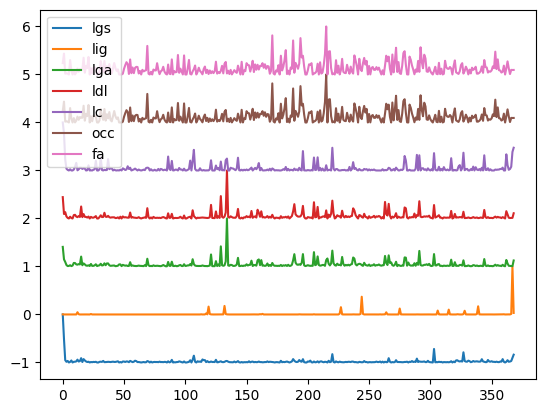

In [ ]:
import matplotlib.pyplot as plt
plt.plot(normalize(lgs_attrib[0].cpu().detach().numpy().var(axis=1))-1)
plt.plot(normalize(lig_attrib[0].cpu().detach().numpy().var(axis=1)))
plt.plot(normalize(lga_attrib[0].cpu().detach().numpy().var(axis=1))+1)
plt.plot(normalize(ldl_attrib[0].cpu().detach().numpy().var(axis=1))+2)
plt.plot(normalize(lc_attrib[0].cpu().detach().numpy().var(axis=1))+3)
plt.plot(normalize(occ_attrib[0].cpu().detach().numpy())+4)
plt.plot(normalize(fa_attrib[0].cpu().detach().numpy())+5)
plt.legend(['lgs', 'lig', 'lga', 'ldl', 'lc', 'occ', 'fa'])
plt.show()


In [ ]:
import torch
def get_attributions_lig(lig, iter, device):
    with torch.amp.autocast('cuda'):
        attributions_ig_l, delta_l = [], []
        for i, r in tqdm(enumerate(iter), total=len(iter)):
            seq_ind, mask = r['seq_ind'].to(device), r['mask'].to(device)
            go_terms = r['GOTerm']
            go_ind  = torch.LongTensor([go_term_map[gt[0]] for gt in go_terms]).to(device)
            reference_indices = token_reference.generate_reference(seq_ind.shape[1], device=device).unsqueeze(0)
            attributions_ig, delta = lig.attribute(seq_ind, reference_indices, target=go_ind,
                                            n_steps=8, return_convergence_delta=True, 
                                            additional_forward_args=(mask.to(device)))
            attributions_ig_l.append(attributions_ig.cpu())
            delta_l.append(delta)
    return attributions_ig_l, delta_l

def get_attributions_ldl(ldl, iter, device):
    with torch.amp.autocast('cuda'):
        attributions_ig_l, delta_l = [], []
        for i, r in tqdm(enumerate(iter), total=len(iter)):
            seq_ind, mask = r['seq_ind'].to(device), r['mask'].to(device)
            go_terms = r['GOTerm']
            go_ind  = torch.LongTensor([go_term_map[gt[0]] for gt in go_terms]).to(device)
            reference_indices = token_reference.generate_reference(seq_ind.shape[1], device=device).unsqueeze(0)
            attributions_ig, delta = lig.attribute(seq_ind, reference_indices, target=go_ind,
                                            n_steps=8, return_convergence_delta=True, 
                                            additional_forward_args=(mask.to(device)))
            attributions_ig_l.append(attributions_ig.cpu())
            delta_l.append(delta)
    return attributions_ig_l, delta_l

  0%|          | 0/53 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [2]:

import pickle
for ds_label in ['csa', 'llps', 'elms']:
    with open(f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}_ig_attr.pkl', 'rb') as f:
        ig_attr = pickle.load(f)
        attribution_scores = ig_attr['attribution_scores']
        print(f"Dataset: {ds_label}, Attribution Scores Shape: {attribution_scores.shape}")

Dataset: csa, Attribution Scores Shape: (784, 850)
Dataset: llps, Attribution Scores Shape: (784, 850)
Dataset: elms, Attribution Scores Shape: (784, 850)


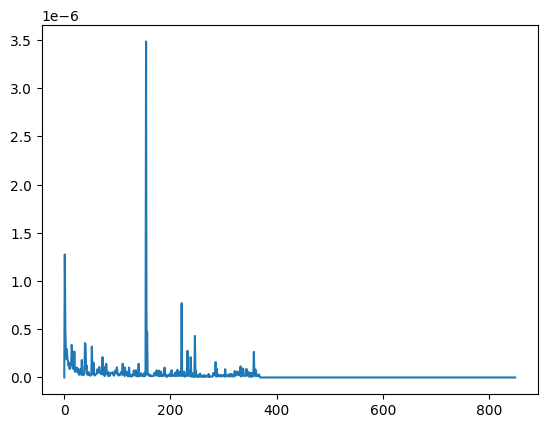

In [20]:
import matplotlib.pyplot as plt
plt.plot(attribution_scores[0])
plt.show()